In [22]:
import json
import os
from pathlib import Path
import pickle
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [23]:
# Experiment definition
exp_group = 'batch_rxbkg_state1_mech1'
exp_name = 'net_newsec_ctrl_var_seed'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name

exp_names_sub = {
    'orig': 'exp_thal_nseed_15_t_200.0_220.0_wmult_0.25_ee_0.5',
    'ctrl': 'exp_thal_nseed_15_t_200.0_220.0_kmu_0.005_ksigma_0.0_taur_100_taum_2500_tauu_100_tc0_10000_tlock_160000_ks_0.0001_ku_0.001_epsm_0.1_wmult_0.25_ee_0.5'
}

# Auto-detect if only one entry exists
for label in exp_names_sub:
    if exp_names_sub[label] is None:
        found = sorted([p.name for p in dirpath_res.iterdir() if p.is_dir()])
        if len(found) == 1:
            exp_names_sub[label] = found[0]
            print(f'Auto-detected exp_name_sub: {found[0]}')
        else:
            print('Available sub-experiments:', found)

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

pop_names = df.index.tolist()

In [24]:
# Load rates from result json files
R_all = {}

for exp_label, exp_name_sub in exp_names_sub.items():
    if exp_name_sub is None:
        print(f'Skipping {exp_label}: exp_name_sub not set')
        continue

    dirpath_data = dirpath_res / exp_name_sub / 'results'
    json_files = sorted(dirpath_data.glob('*.json'))
    n_trials = len(json_files)
    print(f'{exp_label}: {n_trials} trials')

    R = np.full((len(pop_names), n_trials), np.nan)
    for i, fpath in enumerate(json_files):
        with open(fpath, 'r') as fid:
            res = json.load(fid)
        for j, pop in enumerate(pop_names):
            R[j, i] = res['rates'].get(pop, np.nan)

    R = xr.DataArray(
        R,
        dims=['pop', 'trial'],
        coords={'pop': pop_names, 'trial': np.arange(n_trials)}
    )

    # Drop pops with no valid rate in any trial
    R_all[exp_label] = R.sel(pop=~R.isnull().all(dim='trial'))

orig: 15 trials
ctrl: 15 trials


In [25]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS  = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

THAL_E_POPS = ['TC', 'HTC', 'TCM']
THAL_I_POPS = ['TI', 'TIM', 'IRE', 'IREM']
CORE_POPS   = ['TC', 'HTC', 'TI', 'IRE']
MATX_POPS   = ['TCM', 'TIM', 'IREM']
THAL_POPS   = CORE_POPS + MATX_POPS

In [26]:
def plot_rates(
        pops_vis,
        exp_labels=None,
        figsize=(10, 3),
        box_w=0.16, d=0.2,
        target_alpha=1, box_alpha=0.8,
        normalize=False, center=False,
        legend=True, title=True, ylabel=True
        ):
    fig, ax = plt.subplots(figsize=figsize)

    if center and normalize:
        raise ValueError('Cannot center and normalize simultaneously.')

    exp_labels = exp_labels or list(R_all.keys())
    x_base = np.arange(len(pops_vis))
    colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

    exp_labels = [l for l in exp_labels if l is not None]
    offsets = np.linspace(-d, d, len(exp_labels))

    # Target horizontal markers
    d1 = d * 2
    for ix, pop in enumerate(pops_vis):
        if pop not in df.index:
            continue
        if center:
            target = 0
        elif normalize:
            target = 1
        else:
            target = df.loc[pop, 'target_rate']
        ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
                color='black', linewidth=2, linestyle='-', zorder=0, alpha=target_alpha)

    # Grouped boxplots
    def box_props(c):
        return dict(
            patch_artist=True, showmeans=True, meanline=False, whis=1.5, vert=True,
            boxprops=dict(facecolor=(*c, 0.45), edgecolor=c),
            medianprops=dict(color=c, linewidth=1.5),
            whiskerprops=dict(color=c, linewidth=1.2),
            capprops=dict(color=c, linewidth=1.2),
            meanprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='black', markersize=4),
            flierprops=dict(marker='.', markerfacecolor=c,
                            markeredgecolor=c, alpha=box_alpha),
        )

    for offset, exp_label in zip(offsets, exp_labels):
        if exp_label not in R_all:
            continue
        R_exp = R_all[exp_label].reindex(pop=pops_vis)
        data = [R_exp.sel(pop=pop).values for pop in pops_vis]
        data = [y[~np.isnan(y)] for y in data]
        positions = [x_base[ix] + offset for ix, y in enumerate(data) if len(y) > 0]
        if center:
            data_valid = [y - df.loc[pop, 'target_rate']
                          for pop, y in zip(pops_vis, data)
                          if len(y) > 0 and pop in df.index]
        elif normalize:
            data_valid = [y / df.loc[pop, 'target_rate']
                          for pop, y in zip(pops_vis, data)
                          if len(y) > 0 and pop in df.index]
        else:
            data_valid = [y for y in data if len(y) > 0]
        try:
            ax.boxplot(data_valid, positions=positions, widths=box_w,
                       **box_props(colors[exp_label]))
        except Exception:
            pass

    if legend:
        handles = [plt.Line2D([0], [0], color=colors[k], lw=6,
                              alpha=box_alpha, label=k) for k in exp_labels]
        ax.legend(handles=handles)

    ax.set_xticks(x_base)
    ax.set_xticklabels(pops_vis, rotation=90)
    if ylabel:
        if center:
            ax.set_ylabel('r - r0, Hz')
        elif normalize:
            ax.set_ylabel('r / r0')
        else:
            ax.set_ylabel('Rate, Hz')
    if title:
        ax.set_title('Rates by population and trial')

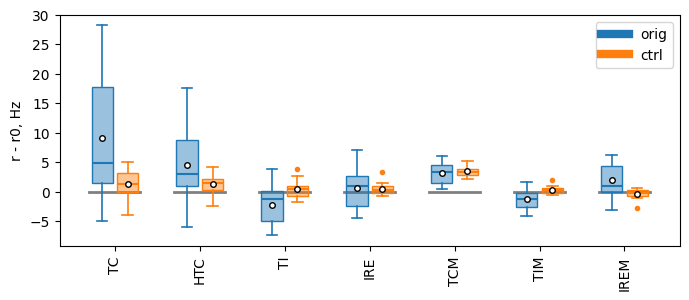

In [27]:
# Rate error boxplots
par = {'figsize': (8, 3), 'target_alpha': 0.5,
       'box_w': 0.25, 'box_alpha': 1, 'd': 0.15,
       'normalize': False, 'center': True, 'legend': True,
       'title': False, 'ylabel': True}
plot_rates(THAL_POPS, **par)

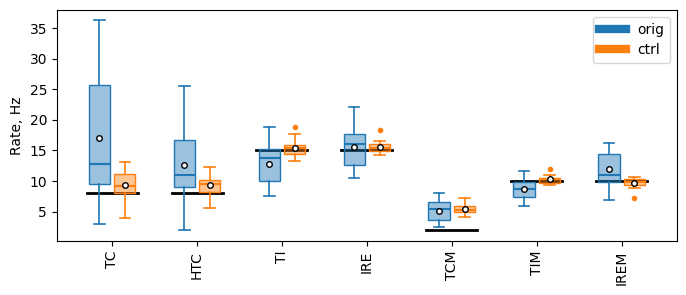

In [28]:
# Absolute rates
par_abs = {'figsize': (8, 3), 'target_alpha': 1,
           'box_w': 0.25, 'box_alpha': 1, 'd': 0.15,
           'normalize': False, 'center': False, 'legend': True,
           'title': False, 'ylabel': True}
plot_rates(THAL_POPS, **par_abs)

In [34]:
# Load ctrl pkl files and extract final z per population per trial
Z_all = {}   # exp_label -> xr.DataArray [pop, trial]

for exp_label, exp_name_sub in exp_names_sub.items():
    if exp_name_sub is None:
        continue

    dirpath_ctrl = dirpath_res / exp_name_sub / 'ctrl'
    pkl_files = sorted(dirpath_ctrl.glob('*.pkl'))
    n_trials = len(pkl_files)
    print(f'{exp_label}: {n_trials} ctrl files')

    # Collect z values: {pop -> [z_trial0, z_trial1, ...]}
    Z_dict = {}
    for i, fpath in enumerate(pkl_files):
        with open(fpath, 'rb') as fid:
            ctrl_data = pickle.load(fid)
        for pop, pdata in ctrl_data.items():
            zvec = pdata.get('zvec', None)  # key is 'zvec' per TRACE_KEY_MAP
            if zvec is None or len(zvec) == 0:
                z_final = np.nan
            else:
                z_final = zvec[-1]
            Z_dict.setdefault(pop, []).append(z_final)

    all_pops = list(Z_dict.keys())
    Z = np.array([[Z_dict[p][i] for i in range(n_trials)] for p in all_pops])
    if len(Z) == 0:
        continue
    Z_all[exp_label] = xr.DataArray(
        Z,
        dims=['pop', 'trial'],
        coords={'pop': all_pops, 'trial': np.arange(n_trials)}
    )

Z_all

orig: 0 ctrl files
ctrl: 15 ctrl files


{'ctrl': <xarray.DataArray (pop: 7, trial: 15)> Size: 840B
 array([[-7.05485080e+01, -3.36735308e+01, -8.14262055e+01,
         -4.40616040e+01, -4.30700939e+01, -4.70938112e+00,
         -5.92524960e+01, -2.37602042e+01, -4.70125295e+01,
         -4.17231223e+01, -8.30389115e+01, -5.42860268e+01,
         -5.58796476e+01, -4.24837008e+01, -7.73018627e+01],
        [-6.55292741e+01, -5.03587041e+01, -5.10226422e+00,
         -2.62985864e+01, -3.15983257e+01, -5.09005091e+01,
         -3.97483765e+01, -3.03651121e+01, -6.31647966e+01,
          1.46720539e+01, -4.96472757e+00, -3.55053859e+01,
          3.71853772e+01, -5.22672400e+01,  1.28167893e+00],
        [-3.12763420e-01,  2.34343095e-01,  2.53075301e-02,
         -3.62819173e-02, -2.31513624e-01,  2.61038943e-02,
          1.03241288e-01, -5.41881648e-01, -1.61884261e-01,
          2.89347404e-01, -3.26926064e-01, -9.31920891e-02,
         -3.87761121e-02, -1.92293917e-01, -2.71938827e-01],
        [-4.32982681e+00, -3.65828939e

In [35]:
def plot_z(
        pops_vis,
        exp_labels=None,
        figsize=(8, 3),
        box_w=0.25, d=0.15,
        box_alpha=0.8,
        legend=True, title=True
        ):
    fig, ax = plt.subplots(figsize=figsize)

    exp_labels = exp_labels or list(Z_all.keys())
    exp_labels = [l for l in exp_labels if l is not None and l in Z_all]
    x_base = np.arange(len(pops_vis))
    colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))
    offsets = np.linspace(-d, d, len(exp_labels)) if len(exp_labels) > 1 else [0.0]

    # Zero line
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)

    def box_props(c):
        return dict(
            patch_artist=True, showmeans=True, meanline=False, whis=1.5, vert=True,
            boxprops=dict(facecolor=(*c, 0.45), edgecolor=c),
            medianprops=dict(color=c, linewidth=1.5),
            whiskerprops=dict(color=c, linewidth=1.2),
            capprops=dict(color=c, linewidth=1.2),
            meanprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='black', markersize=4),
            flierprops=dict(marker='.', markerfacecolor=c,
                            markeredgecolor=c, alpha=box_alpha),
        )

    for offset, exp_label in zip(offsets, exp_labels):
        Z_exp = Z_all[exp_label].reindex(pop=pops_vis)
        data = [Z_exp.sel(pop=pop).values if pop in Z_exp.coords['pop'].values
                else np.array([]) for pop in pops_vis]
        data = [y[~np.isnan(y)] for y in data]
        positions = [x_base[ix] + offset for ix, y in enumerate(data) if len(y) > 0]
        data_valid = [y for y in data if len(y) > 0]

        # Overlay individual points
        for pos, y in zip(positions, data_valid):
            ax.scatter(np.full(len(y), pos), y, s=20, color=colors[exp_label],
                       zorder=5, alpha=0.7)

        if len(data_valid) > 0:
            try:
                ax.boxplot(data_valid, positions=positions, widths=box_w,
                           **box_props(colors[exp_label]))
            except Exception:
                pass

    if legend and len(exp_labels) > 1:
        handles = [plt.Line2D([0], [0], color=colors[k], lw=6,
                              alpha=box_alpha, label=k) for k in exp_labels]
        ax.legend(handles=handles)

    ax.set_xticks(x_base)
    ax.set_xticklabels(pops_vis, rotation=90)
    ax.set_ylabel('z (locked correction)')
    if title:
        ax.set_title('Controller output z after locking')

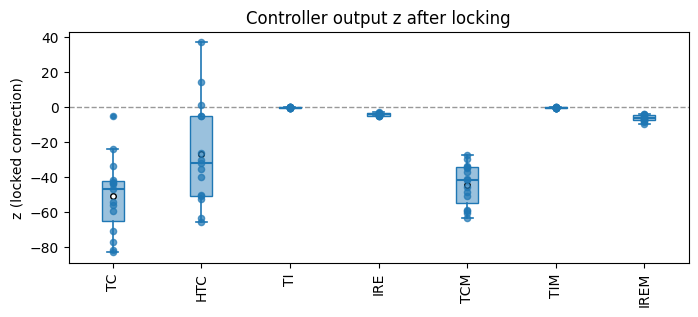

In [36]:
plot_z(THAL_POPS)

In [2]:
import json
from pathlib import Path
import pickle

import numpy as np
import pandas as pd


# Experiment folder
exp_sub_path = Path(
    'exp_results/batch_rxbkg_state1_mech1/net_newsec_ctrl_var_seed/'
    'exp_thal_nseed_15_t_200.0_220.0_kmu_0.005_ksigma_0.0_taur_100_taum_2500_tauu_100_tc0_10000_tlock_160000_ks_0.0001_ku_0.001_epsm_0.1_wmult_0.25_ee_0.5'
)

exp_label = 'CTRL_EXP'   # arbitrary label
out_label = 'ibkg_ctrl_1'       # output filename stem

dirpath_root = Path().resolve().parents[2]
dirpath_sub = exp_sub_path if exp_sub_path.is_absolute() else (dirpath_root / exp_sub_path)

# Load cfg
cfg_files = sorted((dirpath_sub / 'cfg').glob('*.json'))
with open(cfg_files[0], 'r') as fid:
    cfg_json = json.load(fid).get('simConfig', {})

# Extract ctrl gain from cfg
mu_gain = cfg_json.get('ou_ctrl_params', {}).get('mu_gain', None)
if mu_gain is None:
    raise KeyError('mu_gain not found in simConfig.ou_ctrl_params.mu_gain')

# Load ctrl pkl files
dirpath_ctrl = dirpath_sub / 'ctrl'
pkl_files = sorted(dirpath_ctrl.glob('*.pkl'))

trial_data = []  # list of dict(pop -> z_final)
all_pops = set()

# Extract final z per pop per trial
for fpath in pkl_files:
    with open(fpath, 'rb') as fid:
        ctrl_data = pickle.load(fid)

    z_this_trial = {}
    for pop, pdata in ctrl_data.items():
        zvec = pdata.get('zvec', None)
        z_final = np.nan if (zvec is None or len(zvec) == 0) else zvec[-1]
        z_this_trial[pop] = float(z_final) if not np.isnan(z_final) else np.nan
        all_pops.add(pop)

    trial_data.append(z_this_trial)

# Build per-pop arrays aligned across trials
z_per_job = {}
I_per_job = {}
I_median = {}

for pop in sorted(all_pops):
    z_vals = np.array([td.get(pop, np.nan) for td in trial_data], dtype=float)
    mu0 = 0
    I_vals = mu0 + mu_gain * z_vals

    z_per_job[pop] = [None if np.isnan(v) else float(v) for v in z_vals]
    I_per_job[pop] = [None if np.isnan(v) else float(v) for v in I_vals]
    med = np.nanmedian(I_vals)
    I_median[pop] = None if np.isnan(med) else float(med)

# Save output
out = {
    'metadata': {
        'exp_sub_path': str(dirpath_sub),
        'exp_label': exp_label,
        'mu_gain': float(mu_gain),
        'cfg_file_used': str(cfg_files[0]),
    },
    'I_median': I_median,
    'I_per_job': I_per_job,
    'z_per_job': z_per_job,
}

fpath_out = dirpath_sub / f'{out_label}.json'
with open(fpath_out, 'w') as fid:
    json.dump(out, fid, indent=4)

print(f'Saved: {fpath_out}')
pd.DataFrame({'I_median [nA]': I_median}).round(6)


Saved: /ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_rxbkg_state1_mech1/net_newsec_ctrl_var_seed/exp_thal_nseed_15_t_200.0_220.0_kmu_0.005_ksigma_0.0_taur_100_taum_2500_tauu_100_tc0_10000_tlock_160000_ks_0.0001_ku_0.001_epsm_0.1_wmult_0.25_ee_0.5/ibkg_ctrl_1.json


,I_median [nA]
HTC,-0.157992
IRE,-0.019262
IREM,-0.030767
TC,-0.235063
TCM,-0.208839
TI,-0.000466
TIM,-0.000894
